### import required lib

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the dataset
df = pd.read_csv('medical_Diagnosis_dataset.csv')

In [3]:
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,-1.738880,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,-2.934634,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,-1.360209,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,-0.783923,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,-1.928161,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker


## Data Preprocessing

In [4]:
# check the shape of the dataset
df.shape

(1000, 12)

In [5]:
# check the dtypes of the columns
df.dtypes

glucose_level     float64
blood_pressure    float64
cholesterol       float64
bmi               float64
age               float64
feature_6         float64
feature_7         float64
feature_8         float64
feature_9         float64
feature_10        float64
target              int64
smoking_status     object
dtype: object

In [6]:
# check the missing values in the dataset
df.isnull().sum()

glucose_level     0
blood_pressure    0
cholesterol       0
bmi               0
age               0
feature_6         0
feature_7         0
feature_8         0
feature_9         0
feature_10        0
target            0
smoking_status    0
dtype: int64

In [7]:
# check the statistics of the dataset
df.describe()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.987192,0.049559,-0.048558,-0.006647,-0.760523,1.876671,-0.024828,0.034693,0.926480,-0.760954,0.106000
std,0.945743,1.541166,1.711178,0.966008,1.769060,2.217174,1.052177,1.821284,2.070509,1.681686,0.307992
min,-4.247963,-5.446468,-5.558615,-3.688365,-7.844223,-5.639699,-3.221016,-6.274085,-5.495407,-6.626081,0.000000
25%,-1.586288,-0.941598,-1.259443,-0.608662,-2.043784,0.385351,-0.737644,-1.176866,-0.445276,-1.850878,0.000000
50%,-0.987192,0.106014,0.033210,-0.006647,-0.734590,2.047293,-0.060376,0.108569,0.708714,-0.743577,0.000000
75%,-0.432312,1.066150,1.194692,0.603761,0.436495,3.477828,0.730339,1.252404,2.174464,0.357380,0.000000
max,2.695232,4.604960,4.584841,3.529055,5.466089,8.254264,2.943048,5.066045,8.263826,5.379806,1.000000


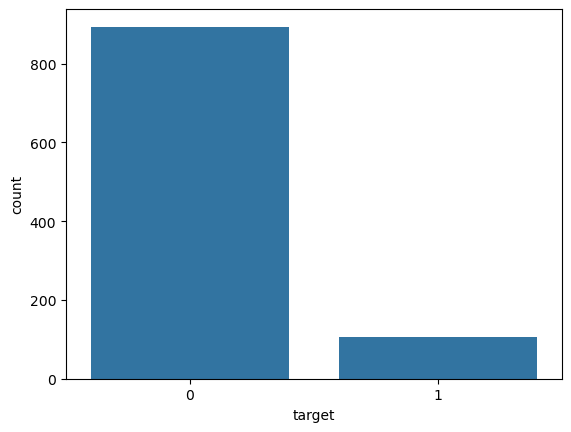

In [8]:
# plot the distribution of the target variable
sns.countplot(x='target', data=df)
plt.show()

In [9]:
# Convert to Realistic Age
df['age'] = (df['age']-df['age'].min()) / (df['age'].max() - df['age'].min())
# range between to 18 and 80
df['age'] = df['age'] * (80 - 18) + 18
# convert to integer
df['age'] = df['age'].astype(int)

In [10]:
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,Former
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,Smoker
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,Non-smoker
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,Non-smoker
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,Non-smoker


In [11]:
# handle the categorical variables
df = pd.get_dummies(df)

In [12]:
df.head()

,glucose_level,blood_pressure,cholesterol,bmi,age,feature_6,feature_7,feature_8,feature_9,feature_10,target,smoking_status_Former,smoking_status_Non-smoker,smoking_status_Smoker
0,-1.030931,1.391626,0.547274,0.928932,46,1.250002,1.332551,1.578256,2.124722,-0.318434,0,True,False,False
1,-1.930636,-0.406752,3.061308,1.083145,40,-1.355054,-1.794192,-0.873019,7.065968,2.110308,0,False,False,True
2,-0.558987,0.299849,1.527071,0.360442,48,1.100793,-0.755951,1.331933,2.041105,-0.824404,0,False,True,False
3,-1.350289,-2.046078,-0.614264,0.126459,50,5.895026,-0.915477,-3.184768,-0.399260,-3.920960,0,False,True,False
4,-0.275754,-0.728495,0.027727,-0.660834,45,3.544945,1.446944,-1.111662,0.313766,-2.376528,0,False,True,False


In [13]:
# convert smoking_status_Former	smoking_status_Non-smoker	smoking_status_Smoker into integer values
df['smoking_status_Former'] = df['smoking_status_Former'].astype(int)
df['smoking_status_Non-smoker'] = df['smoking_status_Non-smoker'].astype(int)
df['smoking_status_Smoker'] = df['smoking_status_Smoker'].astype(int)

In [14]:
df.dtypes

glucose_level                float64
blood_pressure               float64
cholesterol                  float64
bmi                          float64
age                            int64
feature_6                    float64
feature_7                    float64
feature_8                    float64
feature_9                    float64
feature_10                   float64
target                         int64
smoking_status_Former          int64
smoking_status_Non-smoker      int64
smoking_status_Smoker          int64
dtype: object

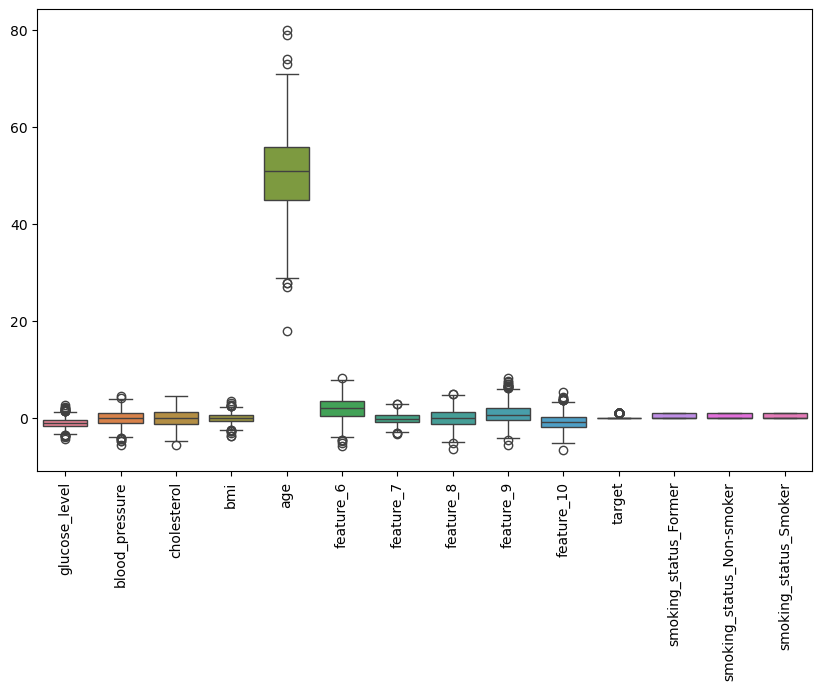

In [15]:
# box plot to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [16]:
# clip the outliers for all columns except the target column
for column in df.columns:
    if column != 'target':
        q1 = df[column].quantile(0.25)
        q3 = df[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])



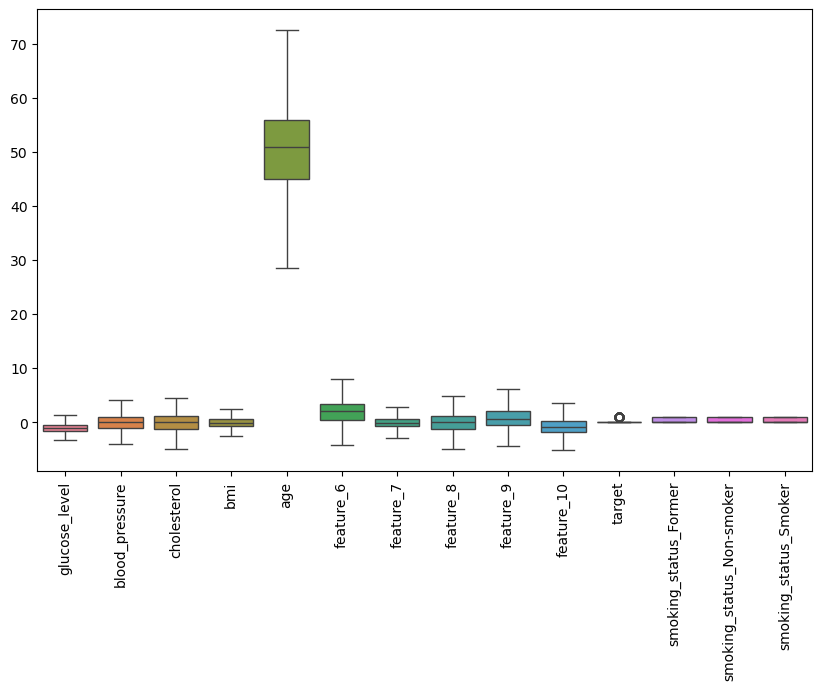

In [17]:
# box plot to check for outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()


In [18]:
# value count target variable
df['target'].value_counts()

target
0    894
1    106
Name: count, dtype: int64

In [19]:
# check the plot for the kernel chossen
#sns.pairplot(df, hue='target')

In [20]:
df['target'].value_counts()

target
0    894
1    106
Name: count, dtype: int64

In [21]:
!pip install -U scikit-learn imbalanced-learn

In [22]:
# handle the class imbalance of df
from imblearn.over_sampling import SMOTE

# divide the dataset into features and target variable
X = df.drop('target', axis=1)
y = df['target']

# split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)




In [27]:
# value count of y 
y_train_smote.value_counts()

target
0    715
1    715
Name: count, dtype: int64

In [24]:
# divide the dataset into features and target variable
X = df.drop('target', axis=1)
y = df['target']

In [25]:
# Model without feature scaling
from sklearn.svm import SVC

# load the model
model = SVC(kernel='rbf', random_state=42)

# fit the model
model.fit(X_train, y_train)

# predict the target variable
y_pred = model.predict(X_test)

In [26]:
# check the accuracy of the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.895
Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.94       179
           1       0.00      0.00      0.00        21

    accuracy                           0.90       200
   macro avg       0.45      0.50      0.47       200
weighted avg       0.80      0.90      0.85       200



c:\Users\Sumit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sumit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sumit\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


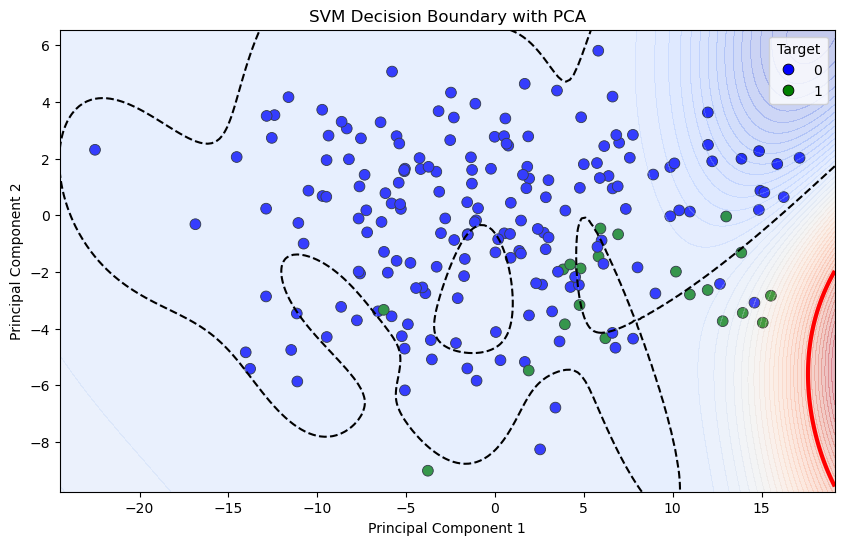

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 6))

# 🔵 Plot points (custom colors)
sns.scatterplot(
    x=X_test_pca[:, 0],
    y=X_test_pca[:, 1],
    hue=y_test,
    palette={0: "blue", 1: "green"},  # custom colors
    edgecolor="black",
    s=60
)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# mesh grid
xx, yy = np.meshgrid(
    np.linspace(xlim[0], xlim[1], 200),
    np.linspace(ylim[0], ylim[1], 200)
)

# decision function
Z = model_pca.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 🔥 Background (soft color)
plt.contourf(xx, yy, Z, levels=50, cmap="coolwarm", alpha=0.3)

# 🔴 DARK boundary line (IMPORTANT)
plt.contour(
    xx, yy, Z,
    levels=[0],            # decision boundary
    colors='red',
    linewidths=3
)

# optional: margins (SVM support margin lines)
plt.contour(
    xx, yy, Z,
    levels=[-1, 1],
    colors='black',
    linestyles='dashed',
    linewidths=1.5
)

plt.title('SVM Decision Boundary with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Target')

plt.show()